<a href="https://colab.research.google.com/github/R12-l/2023-Java-creando-tu-primera-aplicacion/blob/aula-1/C8_29112024.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Estructura de un archivo NIfTI
  # Header (encabezado)
  # Datos de la imagen

!pip install dicom2nifti

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 1.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 29.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.1/13.1 MB 50.5 MB/s eta 0:00:00


In [ ]:
import dicom2nifti
from pathlib import Path
import nibabel as nib
import matplotlib.pyplot as plt

In [ ]:
from google.colab import drive
drive.mount('/content/drive/')

Mounted at /content/drive/


In [ ]:
path_to_dicom = Path('/content/drive/MyDrive/Colab Notebooks/SE000001')

In [ ]:
# Convertir DICOM a NIfTI
dicom2nifti.convert_directory(path_to_dicom, ".")

In [ ]:
nifti = nib.load("201_t2w_tse.nii.gz")

In [ ]:
print(nifti)


<class 'nibabel.nifti1.Nifti1Image'>
data shape (256, 256, 27)
affine:
[[-9.36898887e-01  3.20514254e-02  6.37919828e-02  1.15272324e+02]
 [ 3.03588901e-02  9.27917123e-01 -8.33337128e-01 -9.72956390e+01]
 [ 1.43172191e-02  1.29802674e-01  5.94150448e+00 -8.23735046e+01]
 [ 0.00000000e+00  0.00000000e+00  0.00000000e+00  1.00000000e+00]]
metadata:
<class 'nibabel.nifti1.Nifti1Header'> object, endian='<'
sizeof_hdr      : 348
data_type       : b''
db_name         : b''
extents         : 0
session_error   : 0
regular         : b''
dim_info        : 0
dim             : [  3 256 256  27   1   1   1   1]
intent_p1       : 0.0
intent_p2       : 0.0
intent_p3       : 0.0
intent_code     : none
datatype        : uint16
bitpix          : 16
slice_start     : 0
pixdim          : [-1.         0.9375     0.9375     5.9999995  1.         1.
  1.         1.       ]
vox_offset      : 0.0
scl_slope       : nan
scl_inter       : nan
slice_end       : 0
slice_code      : unknown
xyzt_units      : 2
cal

In [ ]:
nifti.shape

(256, 256, 27)

In [ ]:
image_array = nifti.get_fdata()

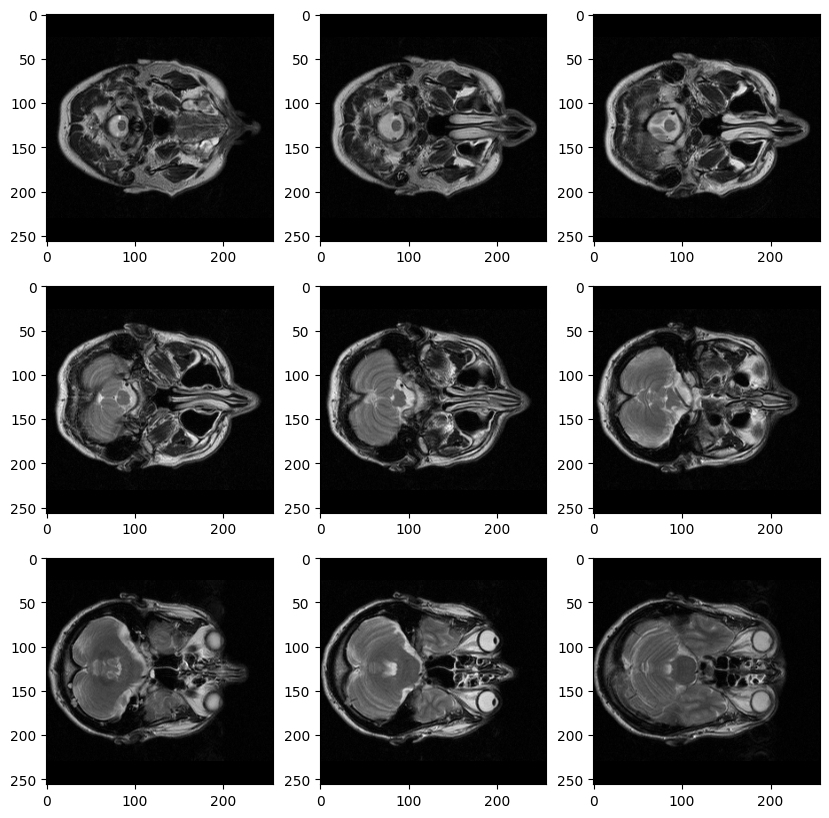

In [ ]:
fig, axis = plt.subplots(3,3, figsize=(10,10))
slice_counter = 0
for i in range(3):
  for j in range(3):
    axis[i][j].imshow(image_array[:,:, slice_counter], cmap = 'gray')
    slice_counter+=1

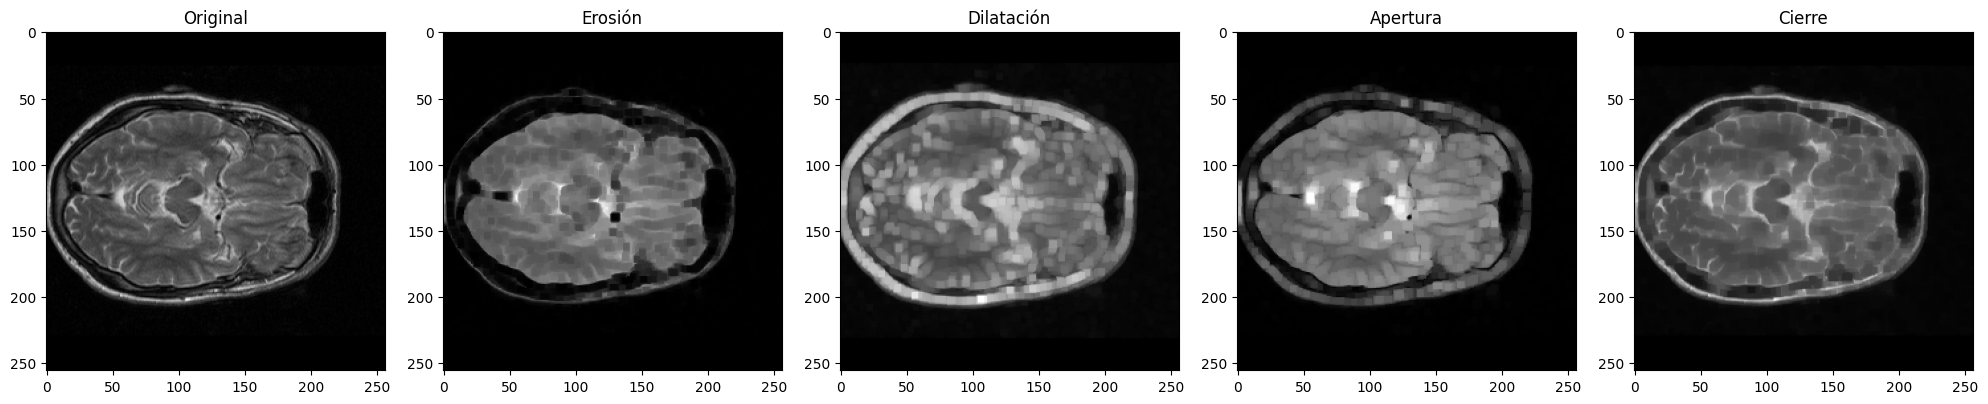

In [ ]:
# Operaciones morfológicas
  # Erosión
  # Dilatación
  # Apertura
  # Cierre
import numpy as np
import cv2

slice_index = 10
image_slice = image_array[:,:, slice_index]

# Normalizar imagen
image_slice_normalized = cv2.normalize(image_slice, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)
# Definir kernel
kernel = np.ones((5,5), np.uint8)
# Aplicar operaciones morfológicas
erosion = cv2.erode(image_slice_normalized, kernel, iterations=1)
dilation = cv2.dilate(image_slice_normalized, kernel, iterations=1)
opening = cv2.morphologyEx(image_slice_normalized, cv2.MORPH_OPEN, kernel)
closing = cv2.morphologyEx(image_slice_normalized, cv2.MORPH_CLOSE, kernel)

# Visualizar resultados
fig, axs = plt.subplots(1, 5, figsize=(20,10))

axs[0].imshow(image_slice_normalized, cmap = 'gray')
axs[0].set_title('Original')

axs[1].imshow(erosion, cmap = 'gray')
axs[1].set_title('Erosión')

axs[2].imshow(dilation, cmap = 'gray')
axs[2].set_title('Dilatación')

axs[3].imshow(opening, cmap = 'gray')
axs[3].set_title('Apertura')

axs[4].imshow(closing, cmap = 'gray')
axs[4].set_title('Cierre')

plt.tight_layout()
plt.show()

In [ ]:
import nibabel as nib
import numpy as np
import matplotlib.pyplot as plt
from ipywidgets import interact, IntSlider

# Cargar archivo
image_data = nifti.get_fdata()

# Función para mostrar un corte interactivo
def show_interactive_slice(axis, index):
  """
  Muestra un corte interactivo en el eje especificado.
  Args:
    axis(int): Eje del corte (0 =X/Sagital, 1=Y/Coronal, 2=Z/Axial)
    index(int): Índice del corte
  """
  if axis == 0:
    img = image_data[index, :, :]
    title = f'Corte Sagital (X) en índice {index}'
  elif axis == 1:
    img = image_data[:, index, :]
    title = f'Corte Coronal (Y) en índice {index}'
  elif axis == 2:
    img = image_data[:, :, index]
    title = f'Corte Axial (Z) en índice {index}'
  else:
    raise ValueError("Eje no válido, elige entre 0 (X), 1 (Y) o 2(Z)")

  # Visualización del corte
  plt.figure(figsize = (10, 8))
  plt.imshow(img.T, cmap = 'gray', origin= 'lower')
  plt.title(title)
  plt.axis('off')
  plt.show()

# Configuración del slider para cortes axiales, sagitales o coronales
def interactive_axis(axis):
  interact(show_interactive_slice,
           axis = IntSlider(value=axis, min=0, max=2, step=1, description ='Eje'),
           index= IntSlider(value=image_data.shape[axis]//2, min=0, max=image_data.shape[axis]-1, step=1, description='Corte'))

# Inicializaer con cortes axiales
interactive_axis(axis=2)

interactive(children=(IntSlider(value=2, description='Eje', max=2), IntSlider(value=13, description='Corte', m…

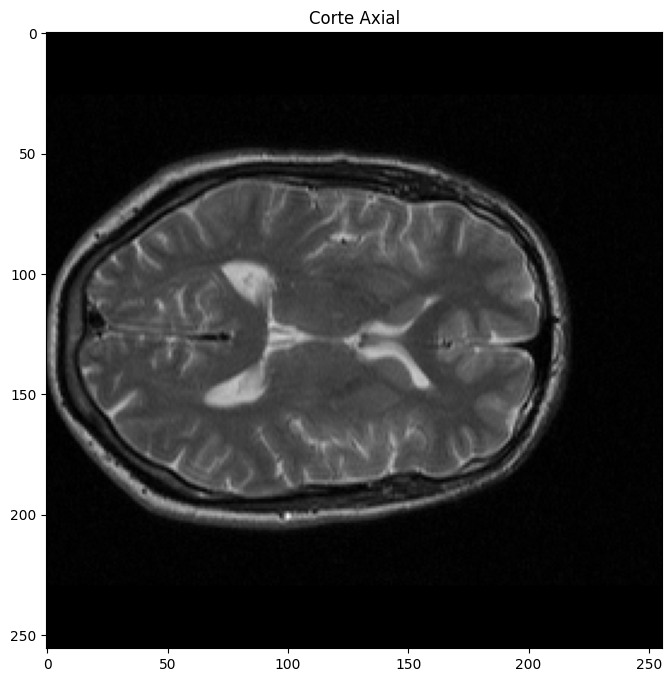

In [ ]:
# Datos de la imagen
image_data = nifti.get_fdata()

plt.figure(figsize=(10,8))
plt.imshow(image_data[:, :, image_data.shape[2]//2], cmap='gray')
plt.title('Corte Axial')
plt.show()

In [ ]:
import os
file_path = '/content/drive/MyDrive/Colab Notebooks/lung_043.nii.gz'
print(os.path.isfile(file_path))

True


In [ ]:
if os.path.isfile(file_path):
  nifti = nib.load(file_path)
  print(nifti)
else:
  print("El archivo no existe o la ruta es incorrecta.")


<class 'nibabel.nifti1.Nifti1Image'>
data shape (512, 512, 129)
affine:
[[  -0.76953101    0.            0.          193.28475952]
 [   0.            0.76953101    0.         -204.34831238]
 [   0.            0.            2.5        -305.5       ]
 [   0.            0.            0.            1.        ]]
metadata:
<class 'nibabel.nifti1.Nifti1Header'> object, endian='<'
sizeof_hdr      : 348
data_type       : b''
db_name         : b''
extents         : 0
session_error   : 0
regular         : b'r'
dim_info        : 0
dim             : [  3 512 512 129   1   1   1   1]
intent_p1       : 0.0
intent_p2       : 0.0
intent_p3       : 0.0
intent_code     : none
datatype        : float32
bitpix          : 32
slice_start     : 0
pixdim          : [-1.        0.769531  0.769531  2.5       0.        0.        0.
  0.      ]
vox_offset      : 0.0
scl_slope       : nan
scl_inter       : nan
slice_end       : 0
slice_code      : unknown
xyzt_units      : 10
cal_max         : 0.0
cal_min         

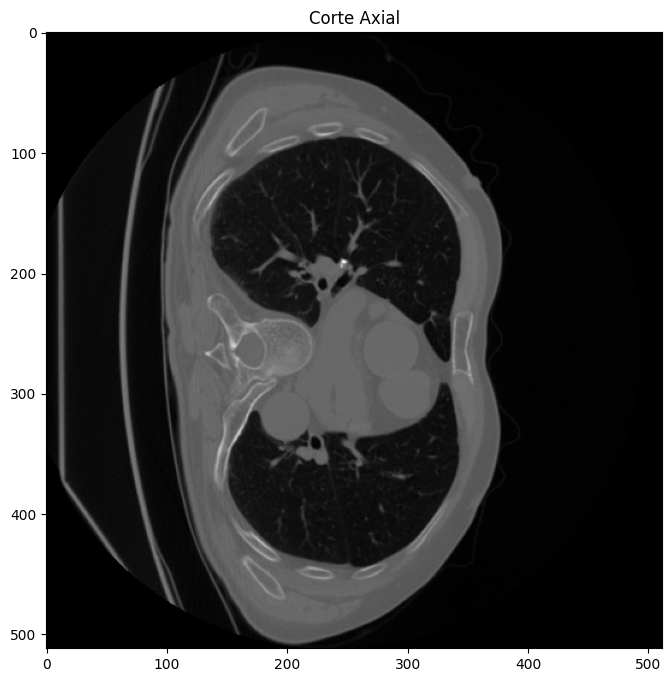

In [ ]:
nifti_img = nib.load(file_path)
# Obtener los datos de la imagen
data = nifti_img.get_fdata()
plt.figure(figsize=(10,8))
plt.imshow(data[:,:, data.shape[2]//2], cmap = 'gray')
plt.title('Corte Axial')
plt.show()

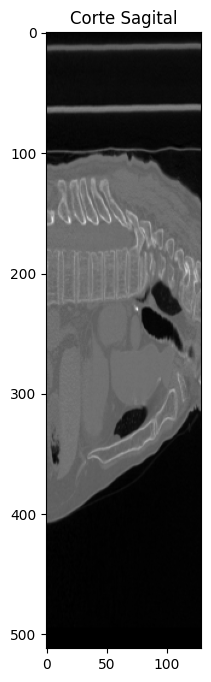

In [ ]:
plt.figure(figsize=(10,8))
plt.imshow(data[data.shape[0]//2,:,:], cmap = 'gray')
plt.title('Corte Sagital')
plt.show()

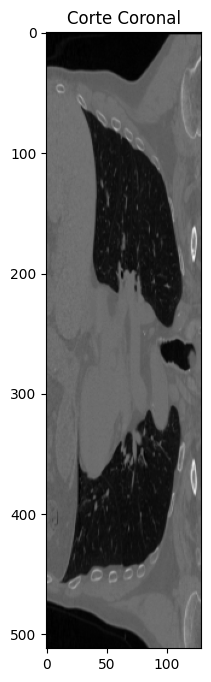

In [ ]:
plt.figure(figsize=(10,8))
plt.imshow(data[:,data.shape[1]//2,:], cmap = 'gray')
plt.title('Corte Coronal')
plt.show()

In [ ]:
import matplotlib
matplotlib.use('Agg')

import matplotlib.pyplot as plt
import matplotlib.animation as animation
import nibabel as nib
import numpy as np

# Cargar el archivo
file_path = '/content/drive/MyDrive/Colab Notebooks/lung_043.nii.gz'
nifti_img = nib.load(file_path)
data = nifti_img.get_fdata()

# Verficar los datos
print("Forma de los datos", data.shape)
print("Valores mínimos y máximos:", np.min(data), np.max(data))

# Mostrar un corte coronal
plt.imshow(data[:, data.shape[1]//2, :], cmap ='gray')
plt.title('Corte coronal')
plt.show()

# Configuración de figura y función para la animación
fig, ax = plt.subplots(figsize=(10, 8))

def update(slice_index):
  ax.clear()
  ax.imshow(data[:, slice_index, :], cmap='gray', vmin=np.min(data), vmax=np.max(data))
  ax.set_title(f'Corte coronal (slice {slice_index})')
  ax.axis('off')

# Crear animación
ani = animation.FuncAnimation(fig, update, frames=range(data.shape[1]), interval = 100, repeat = False)

# Guardar video
ani.save('/content/drive/MyDrive/Video_cornal2024.mp4', writer= 'ffmpeg', fps = 10)

print("El video ha sido guardado como 'video_coronal2024'")

Forma de los datos (512, 512, 129)
Valores mínimos y máximos: -1024.0 1954.0
El video ha sido guardado como 'video_coronal2024'
